c:\Users\Lekas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


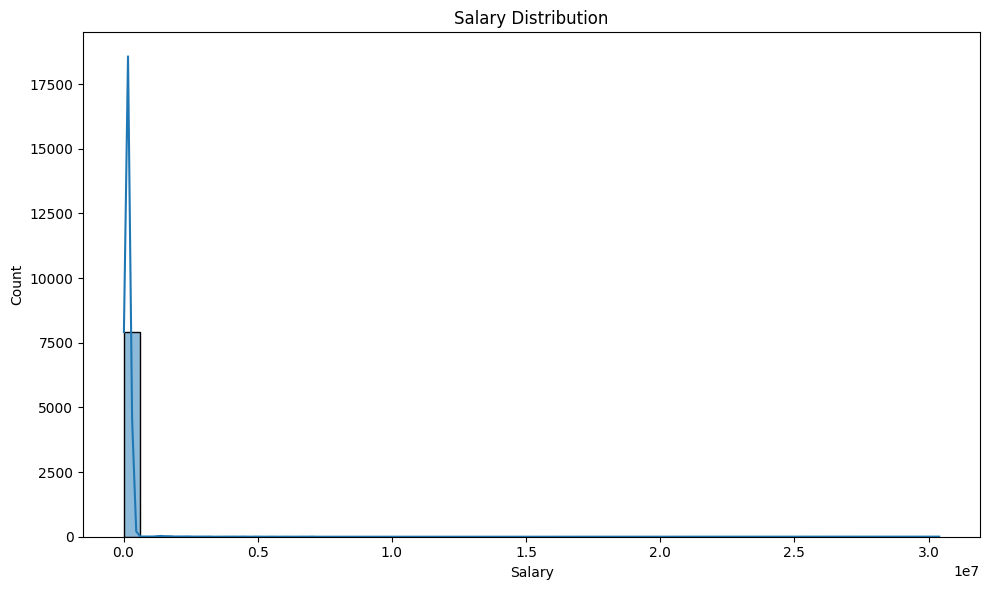

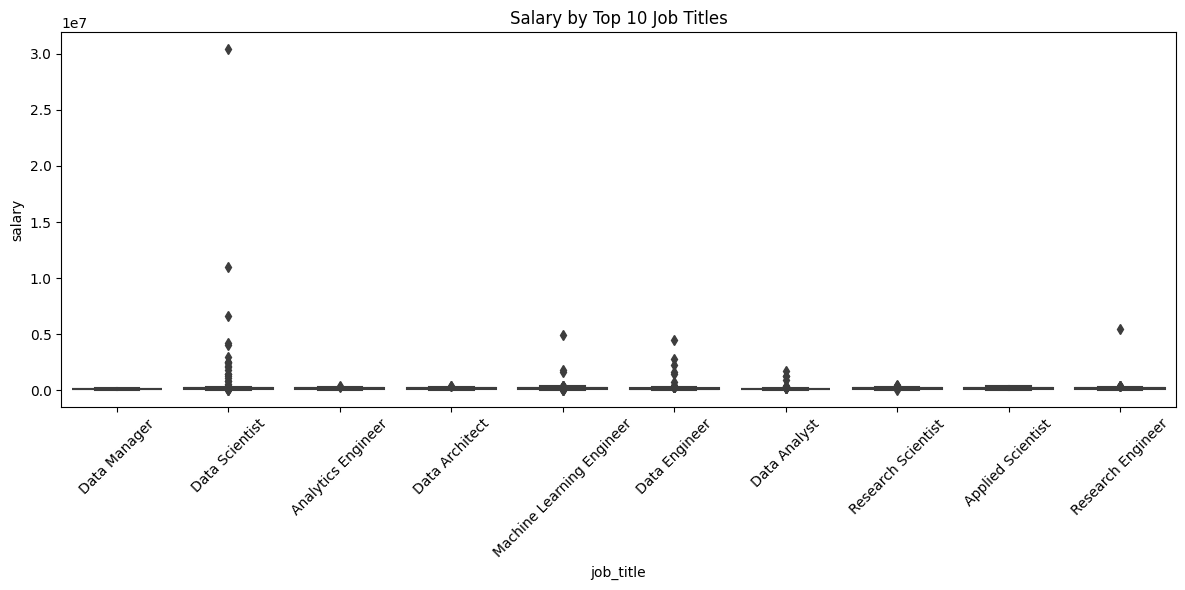

MAE: 55488.68989597395
RMSE: 223599.37699021221
Model saved as src/tech_salary_model.pkl
Predicted Salary: 142496.24854583837


In [5]:
# notebooks/EDA_and_Model.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import os

# Load data
df = pd.read_csv("../data/salaries.csv")

# Preprocess: keep relevant columns, drop NA
df = df[['experience_level','employment_type','job_title','remote_ratio','company_location','salary']].dropna()
categorical_cols = ['experience_level','employment_type','job_title','company_location']
for col in categorical_cols:
    df[col] = df[col].astype(str)

# Create visuals folder if not exists
os.makedirs("../visuals", exist_ok=True)

# --- EDA & Save Visuals ---
plt.figure(figsize=(10,6))
sns.histplot(df['salary'], bins=50, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../visuals/salary_distribution.png")
plt.show()

top_jobs = df['job_title'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x='job_title', y='salary', data=df[df['job_title'].isin(top_jobs)])
plt.xticks(rotation=45)
plt.title("Salary by Top 10 Job Titles")
plt.tight_layout()
plt.savefig("../visuals/salary_by_job_title.png")
plt.show()

# --- Prepare data for modeling ---
X = df[['experience_level','employment_type','job_title','remote_ratio','company_location']]
y = df['salary']

categorical_features = ['experience_level','employment_type','job_title','company_location']
numeric_features = ['remote_ratio']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numeric_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

# Save model in src/ folder
os.makedirs("../src", exist_ok=True)
joblib.dump(model, "../src/tech_salary_model.pkl")
print("Model saved as src/tech_salary_model.pkl")

# Sample prediction
sample = pd.DataFrame({
    'experience_level':['SE'],
    'employment_type':['FT'],
    'job_title':['Data Scientist'],
    'remote_ratio':[50],
    'company_location':['US']
})
pred_salary = model.predict(sample)
print("Predicted Salary:", pred_salary[0])